### MINIPROJETO AVALIATIVO - PIPELINE PREDITIVO MULTICLASSE

### FASE 1 - EDA

Carregando o dataset

In [1]:
#Importa o dataset salvando também em uma pasta "data" do repositório
#Converte de string para inteiro já no início

import os
import numpy as np
from sklearn.datasets import fetch_openml

pasta_dados = "data"
os.makedirs(pasta_dados, exist_ok=True)

caminho_X = os.path.join(pasta_dados, "mnist_X.npy")
caminho_y = os.path.join(pasta_dados, "mnist_y.npy")

if os.path.exists(caminho_X) and os.path.exists(caminho_y):
    print("Carregando MNIST do cache local...")
    X = np.load(caminho_X)
    y = np.load(caminho_y)
else:
    print("Baixando o dataset MNIST...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    
    X = mnist.data
    y = mnist.target.astype(int)  
    
    print("Salvando cache local em /data...")
    np.save(caminho_X, X)
    np.save(caminho_y, y)

print("Finalizou! Shapes:", X.shape, y.shape)
print("Tipo de y:", y.dtype)

Carregando MNIST do cache local...
Finalizou! Shapes: (70000, 784) (70000,)
Tipo de y: int64


Dimensionalidade das matrizes

In [2]:
#Exibe a dimensionalidade

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (70000, 784)
Shape de y: (70000,)


Distribuição das classes

In [3]:
#Mostra o balanceamento das classes

valores, contagens = np.unique(y, return_counts=True)

for v, c in zip(valores, contagens):
    print(f"Dígito {v}: {c} amostras")

Dígito 0: 6903 amostras
Dígito 1: 7877 amostras
Dígito 2: 6990 amostras
Dígito 3: 7141 amostras
Dígito 4: 6824 amostras
Dígito 5: 6313 amostras
Dígito 6: 6876 amostras
Dígito 7: 7293 amostras
Dígito 8: 6825 amostras
Dígito 9: 6958 amostras


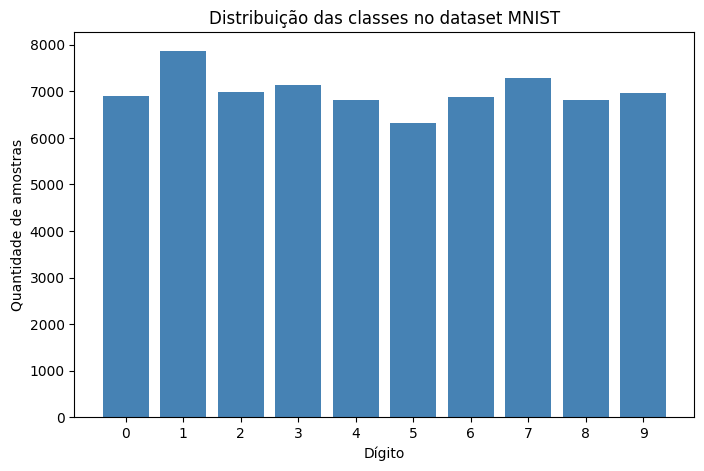

In [4]:
#Mostra o balanceamento como gráfico de barras

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(valores, contagens, color='steelblue')
plt.xlabel("Dígito")
plt.ylabel("Quantidade de amostras")
plt.title("Distribuição das classes no dataset MNIST")
plt.xticks(valores) 
plt.show()

Conclusões iniciais:
- O dataset é aproximadamente balanceado entre as 10 classes, com cada dígito representando por volta de 9-11% do total.
- Mesmo com pequenas variações entre classes, não há um desbalanceamento exagerado.

Grade visual 2x5

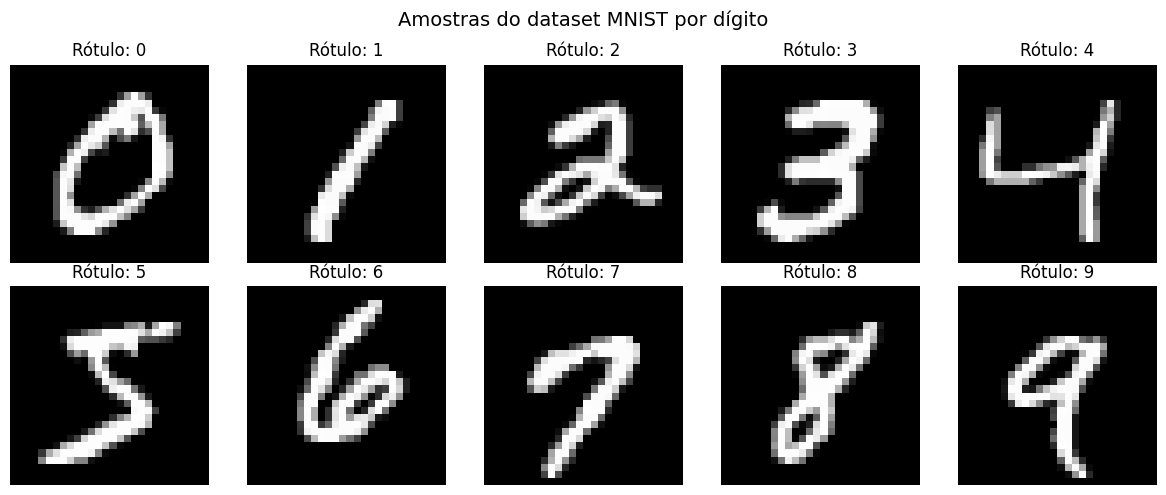

In [5]:
#Exibe imagens de cada dígito juntamente com rótulo

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):
    indice = np.where(y == digito)[0][0]
    imagem = X[indice].reshape(28, 28)

    linha = digito // 5
    coluna = digito % 5
    ax = axes[linha, coluna]

    ax.imshow(imagem, cmap='gray')
    ax.set_title(f"Rótulo: {digito}")
    ax.axis('off')

plt.suptitle("Amostras do dataset MNIST por dígito", fontsize=14)
plt.tight_layout()
plt.show()

-Sobre a escala de pixels (0–255):
Cada pixel de uma imagem em escala de cinza é representado por um número inteiro de 0 a 255.
0 é preto absoluto, 255 é branco absoluto, e os valores intermediários são tons de cinza. Isso vem do fato de que uma imagem em 8 bits por canal consegue representar 2⁸ = 256 níveis de intensidade.

-Sobre a vetorização (28×28 → 784):
A imagem original é uma matriz bidimensional (28 linhas × 28 colunas = 784 posições). Só que a maioria dos algoritmos clássicos de ML (SVM, KNN, Random Forest, Regressão Logística) espera como entrada uma tabela onde cada linha é uma amostra e cada coluna é uma "feature" (característica) numérica, ou seja, um vetor 1D por amostra, não uma matriz 2D. 
Por isso a imagem é "achatada" (flatten): cada um dos 784 pixels vira uma feature independente. É importante ressaltar que essa vetorização perde a noção de vizinhança espacial entre pixels.

### FASE 2 - PIPELINE DE PRÉ-PROCESSAMENTO E DIVISÃO DOS DADOS

Divisão estratificada dos dados

In [6]:
#Aplica a função duas vezes em sequência para possibilitar divisão em 3 partes

from sklearn.model_selection import train_test_split

# Passo 1: separa 20% para teste, sobra 80% (treino + validação)
X_temp, X_teste, y_temp, y_teste = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Passo 2: dos 80% restantes, separa a parte de validação
# 10% do total dividido por 80% (o que sobrou) = 0.125 é o valor que entra no test_size
X_treino, X_val, y_treino, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    stratify=y_temp,
    random_state=42
)

print("Treino:", X_treino.shape[0], "amostras")
print("Validação:", X_val.shape[0], "amostras")
print("Teste:", X_teste.shape[0], "amostras")

Treino: 49000 amostras
Validação: 7000 amostras
Teste: 14000 amostras


Normalização/Escalonamento

In [7]:
#Optou-se por utilizar o MinMaxScaler do scikit-learn

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit_transform SÓ no treino: o scaler aprende min/max a partir do treino
X_treino_norm = scaler.fit_transform(X_treino)

# transform (sem fit) na validação e no teste: aplica os parâmetros já aprendidos
X_val_norm = scaler.transform(X_val)
X_teste_norm = scaler.transform(X_teste)

print("Min:", X_treino_norm.min(), "| Max:", X_treino_norm.max())

Min: 0.0 | Max: 1.0


No dataset atual, a divisão por 255 seria também possível porque os limites já são conhecidos por definição, mas a opção escolhida para normalização foi o MinMaxScaler pois ela atende a maioria dos casos da "vida real" , sendo a prática geral de pré-processamento que se tornaria obrigatória em datasets onde o mínimo/máximo não são conhecidos de antemão.
 

Por que normalizar os dados?

Os pixels das imagens vão de 0 a 255. Se a gente não ajustar essa escala, alguns algoritmos podem ter problemas:

- Para o KNN, que classifica comparando a distância entre os pontos: se os números forem muito grandes, as contas de distância ficam distorcidas e menos precisas.
- Para modelos que aprendem ajustando pesos aos poucos (como Regressão Logística e redes neurais): eles funcionam melhor e aprendem mais rápido quando os números de entrada são pequenos. Com valores até 255, o treinamento pode ficar mais lento ou instável.

Por isso, colocamos todos os pixels na escala de 0 a 1 (dividindo por 255). Isso não muda a informação da imagem, só deixa os números "mais fáceis de digerir" para os modelos, ajudando eles a aprender mais rápido e de forma mais estável.

### FASE 3 - IMPLEMENTAÇÃO E TREINAMENTO DOS 3 MODELOS

MODELOS ESCOLHIDOS:
- KNN (K-Nearest Neighbors) — Escolhido para verificar a performance de um modelo "clássico simples". Ele funciona por analogia direta, comparando a imagem nova com as mais parecidas que já viu. Em imagens de dígitos, tende a funcionar bem, já que dígitos iguais tendem a ter pixels parecidos. É rápido de treinar mas pode ficar lento na hora de prever, porque precisa comparar com todo o conjunto de treino a cada previsão.

- Random Forest — Escolhido para avaliarmos o contraste conceitual com o KNN: em vez de comparar por distância, ele aprende regras de decisão em várias árvores e combina os votos. Costuma performar bem em dados tabulares, é razoavelmente rápido, e vai nos ajudar a comparar "aprendizado baseado em distância" vs. "aprendizado baseado em regras/árvores".

- MLP (rede neural) — Escolhido para representar a abordagem de Deep Learning, contrastando com os dois classificadores clássicos acima. Tende a performar melhor que os dois anteriores, ao custo de mais tempo/complexidade de treino.

Modelo 1 - KNN

In [8]:
#Os hiperparâmetros ajustados foram "n_neighbors" (quantidade de vizinhos consultados)
#e "weights" (forma de ponderar o voto de cada vizinho).

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

valores_k = [3, 5, 9]
resultados_knn = []

for k in valores_k:
    inicio = time.time()
    
    modelo_teste = KNeighborsClassifier(n_neighbors=k, weights='distance')
    modelo_teste.fit(X_treino_norm, y_treino)
    
    pred_val = modelo_teste.predict(X_val_norm)
    acuracia = accuracy_score(y_val, pred_val)
    
    tempo = time.time() - inicio
    resultados_knn.append({'n_neighbors': k, 'acuracia_val': acuracia, 'tempo_s': tempo})
    
    print(f"k={k} | Acurácia na validação: {acuracia:.4f} | Tempo: {tempo:.2f}s")



k=3 | Acurácia na validação: 0.9723 | Tempo: 4.67s
k=5 | Acurácia na validação: 0.9714 | Tempo: 3.22s
k=9 | Acurácia na validação: 0.9689 | Tempo: 3.11s


### Justificativa dos hiperparâmetros escolhidos

Foram testados três valores de "n_neighbors" (3, 5 e 9) no conjunto de validação:

- k=3: acurácia de 0.9723, tempo de 4.67s
- k=5: acurácia de 0.9714, tempo de 3.22s
- k=9: acurácia de 0.9689, tempo de 3.11s

O valor k=3 apresentou a melhor acurácia entre os testados. Isso sugere que, para
este conjunto de dados, considerar poucos vizinhos é suficiente e até vantajoso:
como o MNIST tem uma quantidade grande de exemplos de treino, mesmo com k=3 o
modelo já encontra vizinhos bastante confiáveis e representativos da classe correta.

Conforme k aumenta (5, depois 9), a acurácia cai levemente. Uma explicação
provável é que, ao considerar mais vizinhos, o modelo passa a incluir na votação
imagens que já não são tão parecidas com a amostra analisada, inclusive de
dígitos de classes diferentes, mas com formato parecido (ex: um 4 mal escrito
que se aproxima de um 9) — o que pode "diluir" o voto correto e introduzir erro.

Contudo, vale ressaltar que a diferença entre os três valores testados é pequena, confirmando que o modelo não é muito sensível a essa faixa de k escolhida.

Por isso, o valor final escolhido para o modelo foi k=3.

In [ ]:
#Treinamento final do KNN

inicio = time.time()

knn_final = KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)
knn_final.fit(X_treino_norm, y_treino)

tempo_treino_knn = time.time() - inicio
print(f"Tempo de treino do KNN final: {tempo_treino_knn:.2f} segundos")

Tempo de treino do KNN final: 0.05 segundos


Modelo 2 - Random Forest

In [10]:
#Os hiperparâmetros ajustados foram ''n_estimators'' (número de árvores na floresta)
# e ''max_depth'' (profundidade máxima permitida para cada árvore).

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

combinacoes = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 100, 'max_depth': None},
]

resultados_rf = []

for params in combinacoes:
    inicio = time.time()
    
    modelo_teste = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    modelo_teste.fit(X_treino_norm, y_treino)
    
    pred_val = modelo_teste.predict(X_val_norm)
    acuracia = accuracy_score(y_val, pred_val)
    
    tempo = time.time() - inicio
    resultados_rf.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'acuracia_val': acuracia,
        'tempo_s': tempo
    })
    
    print(f"n_estimators={params['n_estimators']}, max_depth={params['max_depth']} "
          f"| Acurácia: {acuracia:.4f} | Tempo: {tempo:.2f}s")

n_estimators=50, max_depth=10 | Acurácia: 0.9446 | Tempo: 2.38s
n_estimators=100, max_depth=20 | Acurácia: 0.9651 | Tempo: 7.71s
n_estimators=100, max_depth=None | Acurácia: 0.9661 | Tempo: 12.45s


### Justificativa dos hiperparâmetros escolhidos

Foram testadas três combinações de `n_estimators` e `max_depth` no conjunto de validação:

- n_estimators=50, max_depth=10: acurácia de 0.9446 (tempo: 2.38s)
- n_estimators=100, max_depth=20: acurácia de 0.9651 (tempo: 7.71s)
- n_estimators=100, max_depth=None: acurácia de 0.9661 (tempo: 12.45s)

O salto mais significativo de desempenho aconteceu entre a primeira e a segunda
combinação: aumentar o número de árvores (de 50 para 100) e permitir maior
profundidade (de 10 para 20) elevou a acurácia de 0.9446 para 0.9651, um ganho
de cerca de 2 pontos percentuais. Isso indica que, com poucas árvores e pouca
profundidade, o modelo ainda não estava performando bem, as árvores eram simples e
rasas demais para capturar a complexidade dos padrões de pixel que diferenciam
os 10 dígitos.

Já a diferença entre max_depth=20 e max_depth=None (sem limite de profundidade)
foi pequena (0.9651 para 0.9661, menos de 0.1 ponto percentual), mas o tempo de
treino quase dobrou (de 7.71s para 12.45s). Ou seja, deixar as árvores crescerem
sem limite trouxe um ganho marginal de acurácia que não compensa o custo
computacional adicional.

Por esse motivo, a combinação escolhida para o modelo final foi
n_estimators=100, max_depth=20, por oferecer o melhor equilíbrio entre
desempenho preditivo e tempo de treinamento.

In [11]:
#Treinamento final do RandomForest

inicio = time.time()

rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_treino_norm, y_treino)

tempo_treino_rf = time.time() - inicio
print(f"Tempo de treino do Random Forest final: {tempo_treino_rf:.2f} segundos")

Tempo de treino do Random Forest final: 5.51 segundos


Modelo 3 - Rede neural (MLP com Keras)

In [13]:
# Os hiperparâmetros ajustados foram o número de neurônios nas camadas ocultas
# e a taxa de aprendizado (learning rate) do otimizador.

from tensorflow import keras
from tensorflow.keras import layers
import time

configuracoes = [
    {'neuronios': [64, 32], 'learning_rate': 0.001},
    {'neuronios': [128, 64], 'learning_rate': 0.001},
    {'neuronios': [128, 64], 'learning_rate': 0.01},
]

resultados_mlp = []

for config in configuracoes:
    inicio = time.time()
    
    camadas = [layers.Dense(config['neuronios'][0], activation='relu', input_shape=(784,))]
    for n in config['neuronios'][1:]:
        camadas.append(layers.Dense(n, activation='relu'))
    camadas.append(layers.Dense(10, activation='softmax'))
    
    modelo_teste = keras.Sequential(camadas)
    
    otimizador = keras.optimizers.Adam(learning_rate=config['learning_rate'])
    modelo_teste.compile(
        optimizer=otimizador,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    historico = modelo_teste.fit(
        X_treino_norm, y_treino,
        validation_data=(X_val_norm, y_val),
        epochs=10,
        batch_size=32,
        verbose=0
    )
    
    acuracia_val = historico.history['val_accuracy'][-1]
    tempo = time.time() - inicio
    
    resultados_mlp.append({
        'neuronios': config['neuronios'],
        'learning_rate': config['learning_rate'],
        'acuracia_val': acuracia_val,
        'tempo_s': tempo
    })
    
    print(f"neuronios={config['neuronios']}, lr={config['learning_rate']} "
          f"| Acurácia val: {acuracia_val:.4f} | Tempo: {tempo:.2f}s")

c:\Users\eduarda.echer\multiclass-predictive-pipeline\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


neuronios=[64, 32], lr=0.001 | Acurácia val: 0.9706 | Tempo: 17.19s
neuronios=[128, 64], lr=0.001 | Acurácia val: 0.9724 | Tempo: 21.06s
neuronios=[128, 64], lr=0.01 | Acurácia val: 0.9610 | Tempo: 51.50s


### Justificativa dos hiperparâmetros escolhidos

Foram testadas três configurações de arquitetura e taxa de aprendizado no conjunto de validação:

- neurônios=[64, 32], learning_rate=0.001: acurácia de 0.9706 (tempo: 17.19s)
- neurônios=[128, 64], learning_rate=0.001: acurácia de 0.9724 (tempo: 21.06s)
- neurônios=[128, 64], learning_rate=0.01: acurácia de 0.9610 (tempo: 51.50s)

Aumentar a rede de [64, 32] para [128, 64] neurônios (mantendo a mesma learning
rate) trouxe uma pequena melhora na acurácia (de 0.9706 para 0.9724), com um
acréscimo modesto no tempo de treino. Isso indica que a rede maior tem
capacidade um pouco melhor de representar os padrões dos dígitos, sem sinal de
que o custo extra de treino esteja comprometendo a viabilidade do modelo.

Já o aumento da learning rate de 0.001 para 0.01 (mantendo a arquitetura
[128, 64]) piorou a acurácia (de 0.9724 para 0.9610) e não trouxe nenhum
ganho de velocidade — pelo contrário, o tempo de treino praticamente triplicou
(de 21.06s para 51.50s). Isso é consistente com o comportamento esperado de uma
taxa de aprendizado alta demais: os passos de ajuste dos pesos ficam grandes
demais a cada iteração, fazendo o otimizador "pular" o ponto ótimo da função de
perda em vez de convergir suavemente até ele, o que também pode gerar
instabilidade adicional durante o treinamento.

Por esses motivos, a configuração final escolhida foi neurônios=[128, 64],
learning_rate=0.001, por apresentar a melhor acurácia entre as testadas, com
tempo de treino ainda razoável.

In [14]:
#Treinamento final do MLP

inicio = time.time()

modelo_mlp_final = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_mlp_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historico_final = modelo_mlp_final.fit(
    X_treino_norm, y_treino,
    validation_data=(X_val_norm, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

tempo_treino_mlp = time.time() - inicio
print(f"Tempo de treino do MLP final: {tempo_treino_mlp:.2f} segundos")

Epoch 1/15


c:\Users\eduarda.echer\multiclass-predictive-pipeline\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1532/1532 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8615 - loss: 0.4645 - val_accuracy: 0.9540 - val_loss: 0.1506
Epoch 2/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9647 - loss: 0.1212 - val_accuracy: 0.9676 - val_loss: 0.1072
Epoch 3/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9756 - loss: 0.0767 - val_accuracy: 0.9667 - val_loss: 0.1018
Epoch 4/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9827 - loss: 0.0538 - val_accuracy: 0.9684 - val_loss: 0.1085
Epoch 5/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9873 - loss: 0.0393 - val_accuracy: 0.9749 - val_loss: 0.0858
Epoch 6/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9903 - loss: 0.0294 - val_accuracy: 0.9661 - val_loss: 0.1089
Epoch 7/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9915 - loss: 0.0257 - val_accuracy: 0.9713 - val_loss: 0.1067
Epoch 8/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0203 - val_accurac